В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

raw_df = pd.read_csv('train.csv')
print('raw_df.shape :', raw_df.shape)
raw_df.head()

raw_df.shape : (15000, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [2]:
raw_df.info()
print()
print('Пропуски по колонках:')
print(raw_df.isna().sum())
print()
print('Баланс цільової колонки:')
print(raw_df.Exited.value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB

Пропуски по колонках:
id                 0
CustomerId         0
Surname            0
Credit

In [3]:
print(raw_df[['Surname', 'Geography', 'Gender']].nunique())
print()
raw_df.describe().round(2)

Surname      764
Geography      3
Gender         2
dtype: int64



,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.0
mean,7499.50,15691456.68,658.94,37.74,5.03,42729.79,1.59,0.79,0.49,117784.67,0.2
std,4330.27,135205.03,72.26,8.22,2.78,59727.31,0.53,0.41,0.50,45734.45,0.4
min,0.00,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,3749.75,15635143.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83058.14,0.0
50%,7499.50,15690175.00,662.00,37.00,5.00,0.00,2.00,1.00,0.00,123584.87,0.0
75%,11249.25,15757181.50,708.00,42.00,7.00,109531.02,2.00,1.00,1.00,156884.70,0.0
max,14999.00,15815690.00,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48,1.0


In [4]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(raw_df,
                                    test_size=0.2,
                                    random_state=42,
                                    stratify=raw_df.Exited)

print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)
print()
print(train_df.Exited.value_counts(normalize=True))
print(val_df.Exited.value_counts(normalize=True))

train_df.shape : (12000, 14)
val_df.shape : (3000, 14)

Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64
Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [5]:
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
              'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
              'EstimatedSalary']
target_col = 'Exited'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

print('train_inputs:', train_inputs.shape, '| train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape, '| val_targets:', val_targets.shape)
train_inputs.head()

train_inputs: (12000, 10) | train_targets: (12000,)
val_inputs: (3000, 10) | val_targets: (3000,)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [6]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

print('numeric_cols:', numeric_cols)
print('categorical_cols:', categorical_cols)

numeric_cols: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_cols: ['Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean').fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])

print('Пропуски після імпутації (train):', train_inputs[numeric_cols].isna().sum().sum())
print('Пропуски після імпутації (val):', val_inputs[numeric_cols].isna().sum().sum())

Пропуски після імпутації (train): 0
Пропуски після імпутації (val): 0


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,0.54,0.35,0.50,0.21,0.20,0.79,0.49,0.59
std,0.17,0.15,0.28,0.29,0.18,0.41,0.50,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.42
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.62
75%,0.66,0.43,0.70,0.52,0.33,1.00,1.00,0.78
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [9]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False,
                        handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

print('encoded_cols:', encoded_cols)
display(train_inputs.head())
display(val_inputs.head())

encoded_cols: ['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,1.0,0.0,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,1.0,0.0,0.0,1.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,0.0,1.0,0.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,0.0,1.0,0.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,1.0,0.0,0.0,0.0,1.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,0.0,1.0,0.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,1.0,0.0,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,1.0,0.0,0.0,1.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,1.0,0.0,0.0,1.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,0.0,1.0,1.0,0.0


### Висновки до завдання 4

Передобробка даних виконана в чотики кроки, кожен з яких навчався **на тренувальних даних**.

1. **Вилучення нерелевантних ознак.** З вхідних даних виключено `id`, `CustomerId` та `Surname`. Перші дві — технічні ідентифікатори клієнта, які не несуть інформації про його поведінку. `Surname` - прізвище, яке загалом також не несе інформацію про поведінку клієнта.

2. **Заповнення пропущених значень** (`SimpleImputer(strategy='mean')`). У тренувальних даних пропусків немає, але імпутер все одно навчено і збережено: він знадобиться при обробці `test.csv`, де пропуски можуть з'явитися. Обрала середнє, бо береться з самих даних, а не з довільної константи.

3. **Масштабування числових ознак** (`MinMaxScaler`). Діапазони колонок відрізнялись на порядки: `Balance` — до 209 767, `Tenure` — до 10. Без масштабування ознаки з великими значеннями непропорційно впливали б на функцію втрат, а градієнтна оптимізація збігалася б повільніше. Після масштабування всі числові колонки лежать у діапазоні (0, 1).

4. **Кодування категоріальних ознак** (`OneHotEncoder`). `Geography` (3 категорії) та `Gender` (2 категорії) перетворено на 5 бінарних колонок, оскільки логістична регресія працює лише з числами. Параметр `handle_unknown='ignore'` гарантує, що небачена раніше категорія в тестових даних не зламає обробку.

Цільова змінна незбалансована (близько 80% класу 0 і 20% класу 1), тому при розбитті використано `stratify`, а оцінювати модель буду за F1 та AUROC, а не за accuracy.

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [10]:
!pip install pyarrow --quiet

train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

print([f for f in os.listdir('.') if f.endswith('.parquet')])

['val_targets.parquet', 'val_inputs.parquet', 'train_targets.parquet', 'train_inputs.parquet']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [11]:
from sklearn.linear_model import LogisticRegression

X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)

print('X_train:', X_train.shape, '| X_val:', X_val.shape)
print('classes_:', model.classes_)
print('intercept_:', model.intercept_)
print('coef_:', model.coef_.round(2))

X_train: (12000, 13) | X_val: (3000, 13)
classes_: [0. 1.]
intercept_: [-1.40553745]
coef_: [[-0.87  8.45 -0.08 -1.1  -3.93 -0.19 -1.25  0.19 -0.96  0.61 -1.05 -0.27
  -1.13]]


### Висновки до завдання 6

Для навчання моделі відібрано лише підготовлені колонки: `numeric_cols + encoded_cols` — 13 ознак (8 масштабованих числових та 5 закодованих бінарних). Оригінальні текстові колонки `Geography` і `Gender` до `X_train` та `X_val` не потрапили, оскільки вони вже представлені у закодованому вигляді.

**Ваги моделі:**
- **`Age` (+8.45)** — найвпливовіша ознака з великим відривом: чим старший клієнт, тим вища ймовірність відтоку.
- **`NumOfProducts` (−3.93)** — сильний утримувальний фактор: клієнти з більшою кількістю продуктів банку йдуть значно рідше.
- **`IsActiveMember` (−1.25)** та **`Balance` (−1.10)** — активні клієнти й клієнти з більшим балансом схильні залишатися.
- **`Geography_Germany` (+0.61)** — єдина країна з позитивною вагою: у Німеччині відтік вищий, ніж у Франції та Іспанії.

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

Accuracy Training: 87.42%
F1 score Training: 0.64


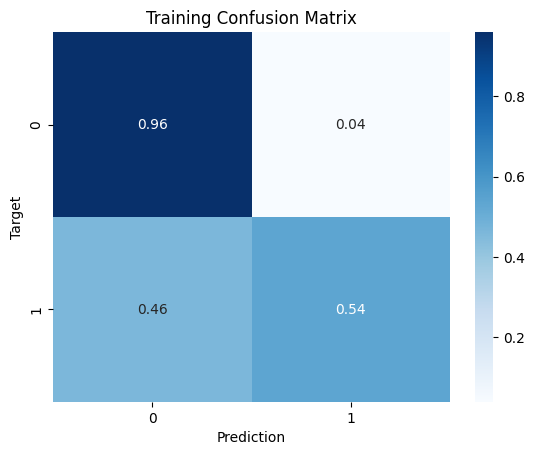

Accuracy Validation: 87.17%
F1 score Validation: 0.64


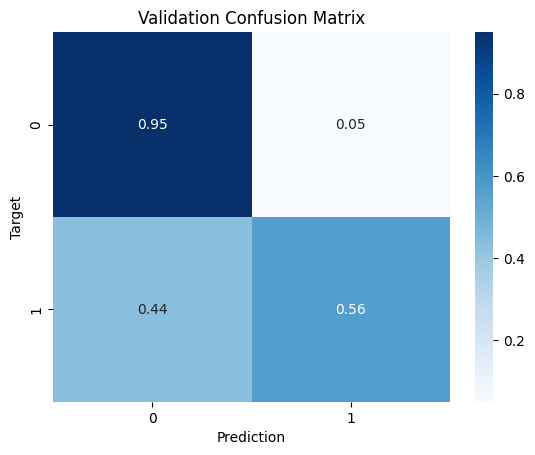

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, pos_label=1.0)
    print("Accuracy {}: {:.2f}%".format(name, accuracy * 100))
    print("F1 score {}: {:.2f}".format(name, f1))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()

    return preds

train_preds = predict_and_plot(X_train, train_targets, 'Training')
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

AUROC for Training: 0.8824


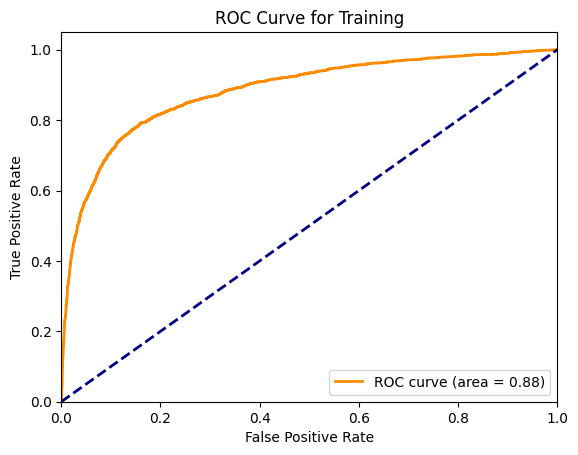

AUROC for Validation: 0.8797


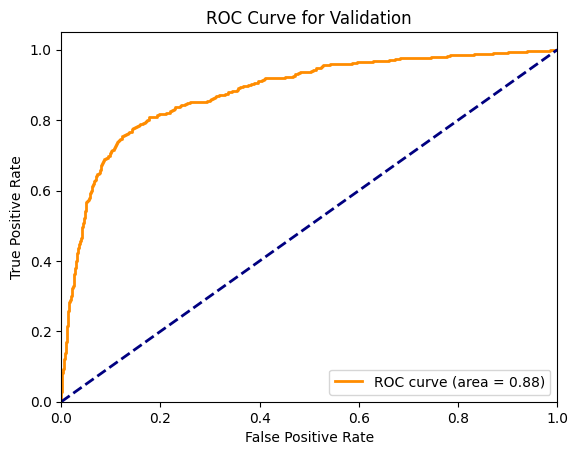

In [13]:
from sklearn.metrics import roc_curve, auc

def compute_auroc_and_build_roc(inputs, targets, name=''):
    # Predict probabilities for the positive class
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1.0)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.4f}')

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()

compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

**Перенавчання відсутнє.** Показники на тренувальних і валідаційних даних майже ідентичні (різниця в AUROC - лише 0.003). Модель не запам'ятала тренувальну вибірку, а вловила загальні закономірності, тому їй можна довіряти на нових даних.

**Confusion matrix виявляє головну слабкість.** Клас 0 (клієнт залишився) розпізнається чудово - 95–96% правильних прогнозів. Але для класу 1 (клієнт пішов) recall становить лише 54–56%: майже половину клієнтів, які реально пішли з банку, модель пропускає. Це наслідок незбалансованості даних - модель зміщена в бік мажоритарного класу.

**Accuracy оманлива.** 87% виглядають вражаюче, але саме через дисбаланс класів ця метрика завищує реальну якість. F1 = 0.64 дає значно чеснішу оцінку, бо враховує і precision, і recall для позитивного класу.

**Загальна оцінка: якість задовільна, з хорошим потенціалом.** AUROC 0.88 означає, що модель добре ранжує клієнтів за ризиком відтоку - якщо взяти випадкового клієнта, який пішов, і випадкового, який залишився, у 88% випадків модель дасть першому вищу ймовірність. Це суттєво краще за випадкове вгадування (0.5).


8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [14]:
# Baseline model: always predicts the majority class
majority_class = train_targets.mode()[0]
print('Мажоритарний клас:', majority_class)

def all_majority(inputs):
    return np.full(len(inputs), majority_class)

print()
print('--- Baseline (завжди мажоритарний клас) ---')
print('Accuracy Training: {:.2f}%'.format(accuracy_score(train_targets, all_majority(X_train)) * 100))
print('Accuracy Validation: {:.2f}%'.format(accuracy_score(val_targets, all_majority(X_val)) * 100))

print()
print('--- Логістична регресія (п.6) ---')
print('Accuracy Training: {:.2f}%'.format(accuracy_score(train_targets, train_preds) * 100))
print('Accuracy Validation: {:.2f}%'.format(accuracy_score(val_targets, val_preds) * 100))

print()
print('F1 baseline Validation: {:.2f}'.format(f1_score(val_targets, all_majority(X_val), pos_label=1.0)))
print('F1 model Validation: {:.2f}'.format(f1_score(val_targets, val_preds, pos_label=1.0)))

Мажоритарний клас: 0.0

--- Baseline (завжди мажоритарний клас) ---
Accuracy Training: 79.65%
Accuracy Validation: 79.67%

--- Логістична регресія (п.6) ---
Accuracy Training: 87.42%
Accuracy Validation: 87.17%

F1 baseline Validation: 0.00
F1 model Validation: 0.64


### Висновки до завдання 8

Мажоритарним класом є `0.0` — клієнт залишився в банку. Модель, яка завжди прогнозує цей клас і повністю ігнорує вхідні дані, досягає accuracy 79.67% просто тому, що такою є частка класу 0 у даних.

**Наша модель кращa за тривіальну, але приріст accuracy скромний** — лише близько 7.5 відсоткових пунктів. Якби ми орієнтувалися виключно на accuracy, могли б помилково вирішити, що 87% — це чудовий результат, хоча половину цієї «якості» забезпечує сам дисбаланс класів.

**F1 показує реальну різницю.** У baseline-моделі F1 = 0.00, бо вона не знаходить жодного клієнта, який пішов: precision і recall для класу 1 дорівнюють нулю. Наша модель має F1 = 0.64 — вона справді навчилася розпізнавати відтік, а не просто вгадувати найчастішу відповідь.


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [15]:
import joblib

log_reg = {
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

joblib.dump(log_reg, 'log_reg.joblib')

# Load the model back from disk
model_2 = joblib.load('log_reg.joblib')

print('Ключі збереженого обʼєкта:', list(model_2.keys()))
print()
val_preds_2 = model_2['model'].predict(X_val)
print('Accuracy завантаженої моделі: {:.2f}%'.format(accuracy_score(val_targets, val_preds_2) * 100))
print('Прогнози збігаються з оригінальними:', (val_preds_2 == val_preds).all())

Ключі збереженого обʼєкта: ['model', 'imputer', 'scaler', 'encoder', 'input_cols', 'target_col', 'numeric_cols', 'categorical_cols', 'encoded_cols']

Accuracy завантаженої моделі: 87.17%
Прогнози збігаються з оригінальними: True


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [16]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(model, imputer, scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    # Work on a copy to keep the original dataframe unchanged
    input_df = input_df[numeric_cols + categorical_cols].copy()

    # Apply the same preprocessing steps as for the training data
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])

    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:, 1]
    return prob

# Check on the first 5 rows of the raw dataframe
predict_raw_df(model, imputer, scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

array([0.00654092, 0.0366679 , 0.37111937, 0.37653484, 0.97577854])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [17]:
test_raw_df = pd.read_csv('test.csv')

print('test_raw_df.shape :', test_raw_df.shape)
print()
print(test_raw_df.isna().sum())
test_raw_df.head()

test_raw_df.shape : (10000, 13)

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [18]:
test_raw_df['Exited'] = predict_raw_df(model, imputer, scaler, encoder,
                                       numeric_cols, categorical_cols, test_raw_df)

print('Розподіл прогнозованих ймовірностей:')
print(test_raw_df.Exited.describe().round(4))
test_raw_df[['id', 'Geography', 'Gender', 'Age', 'Exited']].head()

Розподіл прогнозованих ймовірностей:
count    10000.0000
mean         0.2130
std          0.2555
min          0.0007
25%          0.0352
50%          0.0948
75%          0.2851
max          0.9941
Name: Exited, dtype: float64


,id,Geography,Gender,Age,Exited
0,15000,Germany,Male,30.0,0.075316
1,15001,France,Male,39.0,0.035366
2,15002,France,Male,43.0,0.153210
3,15003,Spain,Male,45.0,0.194872
4,15004,Spain,Male,43.0,0.055660


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [19]:
sample_submission_df = pd.read_csv('sample_submission.csv')

print('sample_submission_df.shape :', sample_submission_df.shape)
print('Колонки:', list(sample_submission_df.columns))
sample_submission_df.head()

sample_submission_df.shape : (10000, 2)
Колонки: ['id', 'Exited']


,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [20]:
submission_df = sample_submission_df[['id']].merge(test_raw_df[['id', 'Exited']], on='id', how='left')

print('submission_df.shape :', submission_df.shape)
print('Пропуски після merge:', submission_df.Exited.isna().sum())
display(submission_df.head())

# Save without row indices
submission_df.to_csv('submission_log_reg.csv', index=False)

print()
print('Перевірка збереженого файлу:')
print(pd.read_csv('submission_log_reg.csv').head())

submission_df.shape : (10000, 2)
Пропуски після merge: 0


,id,Exited
0,15000,0.075316
1,15001,0.035366
2,15002,0.153210
3,15003,0.194872
4,15004,0.055660



Перевірка збереженого файлу:
      id    Exited
0  15000  0.075316
1  15001  0.035366
2  15002  0.153210
3  15003  0.194872
4  15004  0.055660


Функцію `predict_raw_df` адаптовано під наш препроцесинг:
- додано крок **імпутації** через `imputer` — у тестових даних пропуски могли б з'явитися, і без цього кроку модель впала б з помилкою;
- функція працює з **копією** датафрейму, тому оригінальні дані не змінюються;
- `model` та `encoded_cols` більше не беруться з глобальної області, а передаються явно або обчислюються всередині — функція стала самодостатньою.

Прогнози на тестових даних виглядають адекватно: середня прогнозована ймовірність відтоку становить 0.213, що майже збігається з реальною часткою класу 1 у тренувальних даних (0.203). Це хороша ознака — модель не зміщена в жоден бік.